# Importacion de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos

In [2]:
df = pd.read_parquet('peso_bebes.parquet')

In [3]:
df.head()

,source_year,year,month,day,wday,state,is_male,child_race,weight_pounds,plurality,...,alcohol_use,drinks_per_week,weight_gain_pounds,born_alive_alive,born_alive_dead,born_dead,ever_born,father_race,father_age,record_weight
0,2022,2022,4,NaN,5,NaN,False,NaN,6.437498,1,...,None,NaN,30.0,NaN,NaN,NaN,8.0,NaN,49,1
1,2022,2022,3,NaN,5,NaN,False,NaN,7.262027,1,...,None,NaN,99.0,NaN,NaN,NaN,8.0,NaN,45,1
2,2022,2022,12,NaN,2,NaN,True,NaN,6.000983,1,...,None,NaN,54.0,NaN,NaN,NaN,8.0,NaN,38,1
3,2022,2022,10,NaN,4,NaN,True,NaN,8.126239,1,...,None,NaN,30.0,NaN,NaN,NaN,8.0,NaN,39,1
4,2022,2022,11,NaN,4,NaN,False,NaN,7.312733,1,...,None,NaN,10.0,NaN,NaN,NaN,8.0,NaN,40,1


# EDA Inicial

Se limpia y unifica los valores desconocidos de la columna lmp, ya que esta tiene valores de 99 o 9999, reemplazandolos por nulos

In [4]:
def validar_fechas(columna):
    """
    Toma una columna con fechas en formato 'mmddyyyy' o números inválidos,
    valida si son fechas reales y convierte los errores o valores como '99'/'9999' en nulos.
    """

    col_str = columna.astype(str).str.replace('.0', '', regex=False)
    col_str = col_str.apply(lambda x: x.zfill(8) if x not in ['99', '9999', 'nan'] else x)
    columna_limpia = pd.to_datetime(col_str, format='%m%d%Y', errors='coerce')
    
    return columna_limpia

In [5]:
df['lmp'] = validar_fechas(df['lmp'])

In [6]:
total_registros = len(df)


nulos_por_columna = df.isnull().sum()
porcentaje_nulos = (nulos_por_columna / total_registros) * 100


tabla_resumen_nulos = pd.DataFrame({
    'Total_Registros': total_registros,
    'Cantidad_Nulos': nulos_por_columna,
    'Porcentaje_Nulos_(%)': porcentaje_nulos.round(2)
})

tabla_resumen_nulos = tabla_resumen_nulos.sort_values(by='Porcentaje_Nulos_(%)', ascending=False)

tabla_resumen_nulos

,Total_Registros,Cantidad_Nulos,Porcentaje_Nulos_(%)
mother_birth_state,4255156,4255156,100.00
day,4255156,4255156,100.00
state,4255156,4255156,100.00
born_alive_alive,4255156,4255156,100.00
child_race,4255156,4255156,100.00
born_alive_dead,4255156,4255156,100.00
born_dead,4255156,4255156,100.00
apgar_1min,4255156,4255156,100.00
drinks_per_week,4255156,4255156,100.00
mother_residence_state,4255156,4255156,100.00


# Limpieza de datos

Se observa que para las columnas mother_residence_state, born_alive_alive, day, state, child_race, mother_birth_state, born_dead, drinks_per_week, born_alive_dead no se tienen datos en ninguna columna, por lo que se procede a eliminar esas columnas. Las columnas cigarettes_per_day, father_race, mother_race	también se elimina debido a la gran cantidad de nulos.

In [7]:
df = df.drop(columns=['mother_residence_state', 'born_alive_alive', 'day', 'state', 'child_race', 'mother_birth_state', 'born_dead', 'drinks_per_week', 'born_alive_dead', 'cigarettes_per_day', 'cigarettes_per_day', 'father_race', 'mother_race'], errors='ignore')

Eliminamos las columnas apgar_1min y apgar_5min debido a que estas nos dan información posterior del estado del bebé posterior al nacimiento, ocasionando un data lakage, por lo que estas variables no nos sirven para pronosticar el peso del bebé antes del nacimiento.

In [8]:
df = df.drop(columns=['apgar_1min', 'apgar_5min'], errors='ignore')

In [9]:
df[df['source_year']!=df['year']]

,source_year,year,month,wday,is_male,weight_pounds,plurality,mother_age,gestation_weeks,lmp,mother_married,cigarette_use,alcohol_use,weight_gain_pounds,ever_born,father_age,record_weight


Se observa que las columnas source_year y year son redudantes y no aportan nueva información, por lo tanto eliminamos una de ellas

In [10]:
df = df.drop(columns=['source_year'], errors='ignore')

Para el caso de cigarette_use y alcohol_use prefiero rellenar los nulos con una etiqueta que sea "Unknown" de esta manera le digo al modelo que la falta de información es un patrón

In [11]:
df.alcohol_use.unique()

array([None, False, True], dtype=object)

In [12]:
mapeo = {
    True: 1, False: 0
}

df['cigarette_use'] = df['cigarette_use'].map(mapeo)
df['alcohol_use'] = df['alcohol_use'].map(mapeo)

df['cigarette_use'] = df['cigarette_use'].fillna(-1)
df['alcohol_use'] = df['alcohol_use'].fillna(-1)

df.alcohol_use.unique()

array([-1.,  0.,  1.])

Decido borrar la columna lmp porque tiene un alto porcentaje de nulos y puede tener información redudante con la variable gestation_weeks (que tiene menos nulos), ya que la fecha de ultima menstruación se utiliza para identificar cuantas semanas de embarazo tiene la madre, además las fechas no aportan información valiosa a un modelo.

In [13]:
df = df.drop(columns=['lmp'], errors='ignore')

Debido a la baja cantidad de nulos decido imputar con la mediana las columnas 'weight_gain_pounds', 'ever_born', 'gestation_weeks'

In [14]:
columnas_a_imputar = ['weight_gain_pounds', 'ever_born', 'gestation_weeks']

for col in columnas_a_imputar:
    if col in df.columns:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)

Al ser weight_pounds la variable objetivo y no tener tantos valores nulos, decido eliminar esos registros

In [15]:
df = df.dropna(subset=['weight_pounds'])

Las columnas year y record_weight solo tienen un valor, no nos aporta información, por lo cual se decide eliminarla

In [16]:
df['year'].unique()

array([2022], dtype=int64)

In [17]:
df['record_weight'].unique()

array([1], dtype=int64)

In [18]:
df = df.drop(columns=['year', 'record_weight'], errors='ignore')

Se observa que el dataset ya se encuentra depurado

In [19]:
total_registros = len(df)


nulos_por_columna = df.isnull().sum()
porcentaje_nulos = (nulos_por_columna / total_registros) * 100


tabla_resumen_nulos = pd.DataFrame({
    'Total_Registros': total_registros,
    'Cantidad_Nulos': nulos_por_columna,
    'Porcentaje_Nulos_(%)': porcentaje_nulos.round(2)
})

tabla_resumen_nulos = tabla_resumen_nulos.sort_values(by='Porcentaje_Nulos_(%)', ascending=False)

tabla_resumen_nulos

,Total_Registros,Cantidad_Nulos,Porcentaje_Nulos_(%)
month,4250791,0,0.0
wday,4250791,0,0.0
is_male,4250791,0,0.0
weight_pounds,4250791,0,0.0
plurality,4250791,0,0.0
mother_age,4250791,0,0.0
gestation_weeks,4250791,0,0.0
mother_married,4250791,0,0.0
cigarette_use,4250791,0,0.0
alcohol_use,4250791,0,0.0


# Análisis de Negocio

In [62]:
df_eda = df.sample(n=100000, random_state=42)

Se hace el EDA con una submuestra aleatoria de los datos 

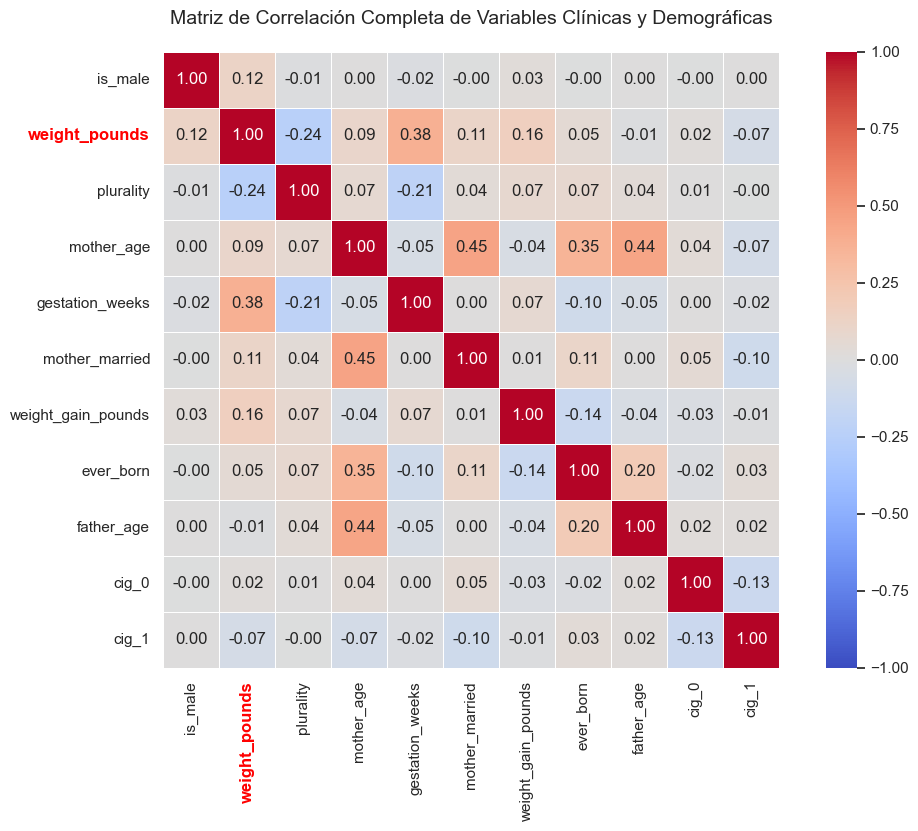

In [64]:
plt.figure(figsize=(12, 8))
corr_matrix = df_eda.corr(method='spearman')


ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
                 vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title('Matriz de Correlación Completa de Variables Clínicas y Demográficas', fontsize=14, pad=20)

for label in ax.get_yticklabels():
    if label.get_text() == 'weight_pounds':
        label.set_color('red')
        label.set_weight('bold')
        label.set_size(12)

for label in ax.get_xticklabels():
    if label.get_text() == 'weight_pounds':
        label.set_color('red')
        label.set_weight('bold')
        label.set_size(12)

plt.show()

- La variable gestation_weeks presenta la mayor correlación positiva (0.55) con weight_pounds. Esto confirma que la duración del embarazo es el predictor individual más fuerte para determinar el peso del bebé.

- La pluralidad del embarazo (plurality) muestra una importante correlación negativa (-0.31). Esto demuestra que los embarazos múltiples reducen drásticamente el peso individual de los bebes.

- Las variables temporales como month y wday tienen una correlación estadísticamente nula (0.00 y -0.01) frente a la variable objetivo, validando la decisión de descartarlas del modelo predictivo para evitar ruido.

- Existe una correlación perfecta (1.00) entre cigarette_use y alcohol_use. Para evitar problemas de multicolinealidad vamos a eliminar una de ellas.

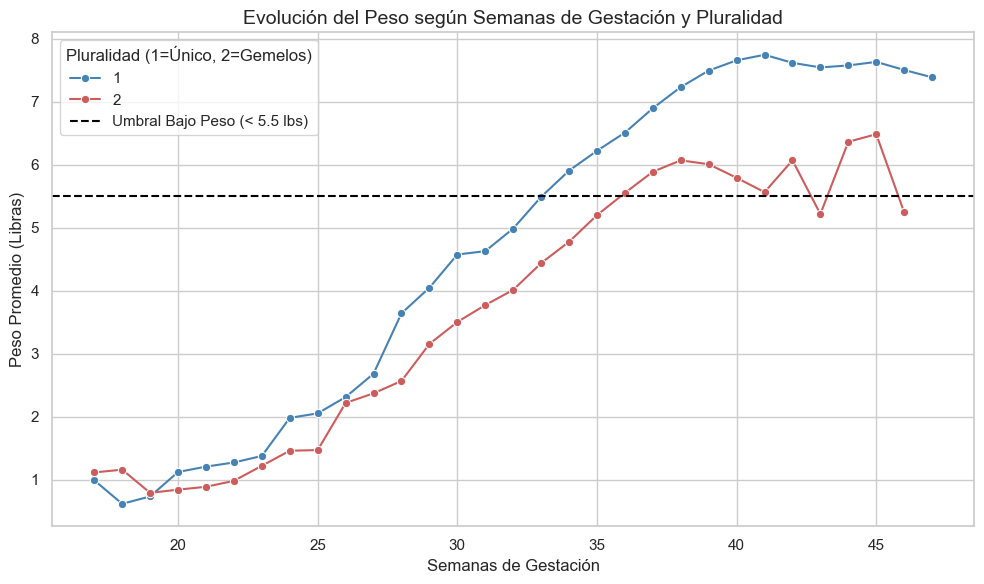

In [22]:
df_interaccion = df_eda[df_eda['plurality'].isin([1, 2])]

sns.lineplot(data=df_interaccion, x='gestation_weeks', y='weight_pounds', 
             hue='plurality', palette=['steelblue', 'indianred'], errorbar=None, marker="o")

plt.axhline(y=5.5, color='black', linestyle='--', label='Umbral Bajo Peso (< 5.5 lbs)')
plt.title('Evolución del Peso según Semanas de Gestación y Pluralidad', fontsize=14)
plt.xlabel('Semanas de Gestación')
plt.ylabel('Peso Promedio (Libras)')
plt.legend(title='Pluralidad (1=Único, 2=Gemelos)')
plt.tight_layout()
plt.show()

Los gemelos tienen un peso inferior a los bebés únicos en cualquier semana de gestación. Mientras un bebé único cruza el umbral seguro de las 5.5 libras hacia la semana 34, un gemelo promedio apenas lo alcanza en la semana 36.

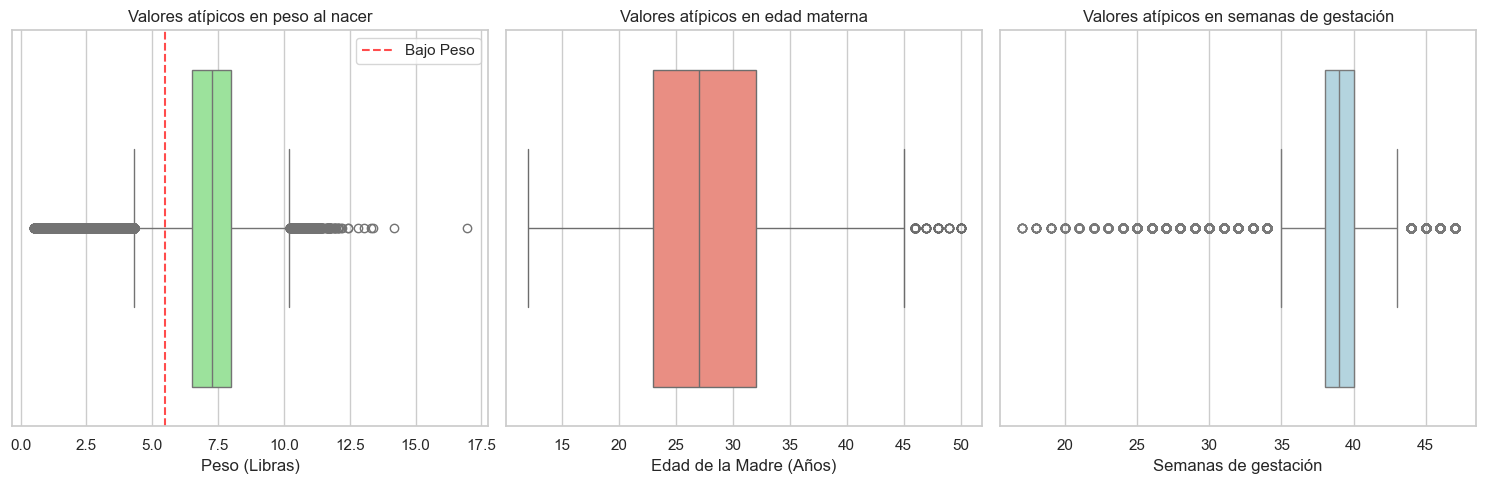

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_eda, x='weight_pounds', ax=axes[0], color='lightgreen')
axes[0].set_title('Valores atípicos en peso al nacer')
axes[0].set_xlabel('Peso (Libras)')
axes[0].axvline(x=5.5, color='red', linestyle='--', alpha=0.7, label='Bajo Peso')
axes[0].legend()

sns.boxplot(data=df_eda, x='mother_age', ax=axes[1], color='salmon')
axes[1].set_title('Valores atípicos en edad materna')
axes[1].set_xlabel('Edad de la Madre (Años)')

sns.boxplot(data=df_eda, x='gestation_weeks', ax=axes[2], color='lightblue')
axes[2].set_title('Valores atípicos en semanas de gestación')
axes[2].set_xlabel('Semanas de gestación')

plt.tight_layout()
plt.show()

Se obervan errores evidentes en la base de datos de la EPS. Se observan registros de bebés con pesos cercanos a 0 libras o superiores a 15 libras. Para evitar bajar la precisión del modelo, se va a aplicar un filtro que restrinja el entrenamiento únicamente a rangos normales.

In [24]:
df_eda['categoria_peso'] = np.where(df_eda['weight_pounds'] < 5.5, '1. Bajo Peso (< 5.5 lbs)', '2. Peso Normal (>= 5.5 lbs)')

columnas_perfil = ['gestation_weeks', 'mother_age', 'weight_gain_pounds']

perfil_riesgo = df_eda.groupby('categoria_peso')[columnas_perfil].mean().round(1)

print("\n" + "="*70)
print("PERFIL PROMEDIO: BEBÉ EN RIESGO VS BEBÉ SANO")
print("="*70)
display(perfil_riesgo)

df_eda = df_eda.drop(columns=['categoria_peso'])


PERFIL PROMEDIO: BEBÉ EN RIESGO VS BEBÉ SANO


,gestation_weeks,mother_age,weight_gain_pounds
categoria_peso,,,
1. Bajo Peso (< 5.5 lbs),34.2,27.6,34.1
2. Peso Normal (>= 5.5 lbs),38.9,27.4,35.6


la edad de la madre es estadísticamente irrelevante (27.6 vs 27.4 años) para determinar el riesgo a nivel macro.

Se filtran las columnas irrelevantes y se depuran los outliers de las variables. Para las variables mother_age y weight_gain_pounds se usa el IQR para hacer el filtrado de los outliers. Para weight_pounds y gestation_weeks se usan valores biológicos posibles

In [25]:
df = df.drop(columns=['month', 'wday', 'alcohol_use'], errors='ignore')

In [26]:
def filtrar_outliers_iqr(dataframe, columna, factor=1.5):
    """
    Filtra los valores atípicos de un dataframe usando el método del Rango Intercuartílico (IQR).
    """
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - (factor * IQR)
    limite_superior = Q3 + (factor * IQR)
    
    # Filtramos el dataframe conservando solo lo que está dentro de los límites
    df_filtrado = dataframe[(dataframe[columna] >= limite_inferior) & (dataframe[columna] <= limite_superior)]
    
    # Imprimimos un resumen de lo que se eliminó
    eliminados = len(dataframe) - len(df_filtrado)
    print(f"Columna '{columna}': Se eliminaron {eliminados} registros atípicos (IQR).")
    
    return df_filtrado

df = filtrar_outliers_iqr(df, 'mother_age')
df = filtrar_outliers_iqr(df, 'weight_gain_pounds')

Columna 'mother_age': Se eliminaron 4213 registros atípicos (IQR).
Columna 'weight_gain_pounds': Se eliminaron 320505 registros atípicos (IQR).


In [27]:
df = df[(df['weight_pounds'] >= 1.0) & (df['weight_pounds'] <= 14.0)]
df = df[(df['gestation_weeks'] >= 24) & (df['gestation_weeks'] <= 45)]

# Preparación de los datos

Volvemos la variables booleanas en enteros

In [28]:
df['is_male'] = df['is_male'].astype(int)
df['mother_married'] = df['mother_married'].astype(int)
df['cigarette_use'] = df['cigarette_use'].astype(int)

Aplicamos OHE a la variable cigarette_use ya que es categorica

In [29]:
df = pd.get_dummies(df, columns=['cigarette_use'], prefix='cig', dtype=int)

df = df.drop(columns=['cig_-1'])

# Split dataset

Hacemos la división de los datos 70/20/10

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X = df.drop(columns=['weight_pounds'])
y = df['weight_pounds']

In [32]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.33, random_state=42
)

print(f"Entrenamiento (70%): {len(X_train)} registros")
print(f"Validación    (20%): {len(X_val)} registros")
print(f"Prueba        (10%): {len(X_test)} registros")

Entrenamiento (70%): 2732991 registros
Validación    (20%): 784759 registros
Prueba        (10%): 386524 registros


In [33]:
import pickle, os

datasets = {
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test
}

if not os.path.exists('datasets'):
    os.makedirs('datasets')

with open('datasets/datasets_finales.pkl', 'wb') as f:
    pickle.dump(datasets, f)

# Función evaluación del modelo

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, recall_score

def evaluar_modelo(modelo, y_real, y_pred, umbral_riesgo=5.5):
    """
    Calcula las 4 métricas clave para el caso de la EPS PUJ.
    Incluye MAE, RMSE, R2 y el Recall de Bajo Peso.
    """
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    
    y_real_bin = (y_real < umbral_riesgo).astype(int)
    y_pred_bin = (y_pred < umbral_riesgo).astype(int)
    
    recall = recall_score(y_real_bin, y_pred_bin)
    
    metricas = {
        'Modelo': [modelo],
        'MAE': [mae],
        'RMSE': [rmse],
        'R²': [r2],
        'Recall': [recall]
    }
    
    df_res = pd.DataFrame(metricas).T
    df_res.columns = ['Valor']
    
    print("-" * 30)
    print("📋 EVALUACIÓN INTEGRAL DEL MODELO")
    print("-" * 30)
    return df_res

# Entrenamiento Línea base

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [49]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
y_pred_val = modelo_lr.predict(X_val)

evaluar_modelo('Regresion lineal', y_val, y_pred_val)

------------------------------
📋 EVALUACIÓN INTEGRAL DEL MODELO
------------------------------


,Valor
Modelo,Regresion lineal
MAE,0.789635
RMSE,1.017791
R²,0.347204
Recall,0.344537


# SVM

In [51]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [52]:
X_train_scaled = scaler.fit_transform(X_train)

In [40]:
scaler = StandardScaler()

svm_reg = LinearSVR(
    dual=False, 
    loss='squared_epsilon_insensitive',
    epsilon=0.1, 
    random_state=42, 
    max_iter=2000
)

In [ ]:

svm_reg.fit(X_train_scaled, y_train)

,epsilon,0.1
,tol,0.0001
,C,1.0
,loss,'squared_epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,False
,verbose,0
,random_state,42
,max_iter,2000


In [42]:
X_val_scaled = scaler.transform(X_val)
y_pred_svm = svm_reg.predict(X_val_scaled)

evaluar_modelo('SVM', y_val, y_pred_svm)

------------------------------
📋 EVALUACIÓN INTEGRAL DEL MODELO
------------------------------


,Valor
Modelo,SVM
MAE,0.789654
RMSE,1.017794
R²,0.347201
Recall,0.344486


In [53]:
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
import pandas as pd

param_grid_svm = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1]
}

grid_svm = GridSearchCV(
    LinearSVR(dual=True, loss='epsilon_insensitive', max_iter=5000, random_state=42),
    param_grid=param_grid_svm,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

print("Iniciando Grid Search para SVM...")
grid_svm.fit(X_train_scaled, y_train)

print("\n" + "="*45)
print("🏆 MEJOR CONFIGURACIÓN SVM")
print("="*45)
print(f"Mejores Parámetros: {grid_svm.best_params_}")
print(f"Mejor MAE (en muestra): {-grid_svm.best_score_:.4f}")

Iniciando Grid Search para SVM...


KeyboardInterrupt: 

In [ ]:
y_pred_svm = grid_svm.predict(X_val_scaled)
evaluar_modelo('SVM_Grid', y_val, y_pred_svm)

# LightGBM (Gradient Boosting)

In [47]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [500, 1000],          
    'learning_rate': [0.01, 0.05, 0.1], 
    'num_leaves': [31, 63],            
    'subsample': [0.8, 1.0],
}

grid_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)


print("Iniciando Grid Search para LightGBM...")
grid_lgbm.fit(X_train, y_train)


print("\n" + "="*45)
print("🏆 RESULTADOS DEL GRID SEARCH")
print("="*45)
print(f"Mejores Parámetros: {grid_lgbm.best_params_}")
print(f"Mejor MAE (CV): {-grid_lgbm.best_score_:.4f}")


mejor_lgbm = grid_lgbm.best_estimator_
y_pred_final = mejor_lgbm.predict(X_val)

mae_final = mean_absolute_error(y_val, y_pred_final)
r2_final = r2_score(y_val, y_pred_final)

print(f"MAE Final en Validación: {mae_final:.4f}")
print(f"R² Final en Validación:  {r2_final:.4f}")

Iniciando Grid Search para LightGBM...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071964 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 211
[LightGBM] [Info] Number of data points in the train set: 2732991, number of used features: 10
[LightGBM] [Info] Start training from score 7.209090

🏆 RESULTADOS DEL GRID SEARCH
Mejores Parámetros: {'learning_rate': 0.05, 'n_estimators': 500, 'num_leaves': 63, 'subsample': 0.8}
Mejor MAE (CV): 0.7602
MAE Final en Validación: 0.7617
R² Final en Validación:  0.3903


C:\Users\crist\AppData\Local\Temp\ipykernel_5860\3573563462.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')


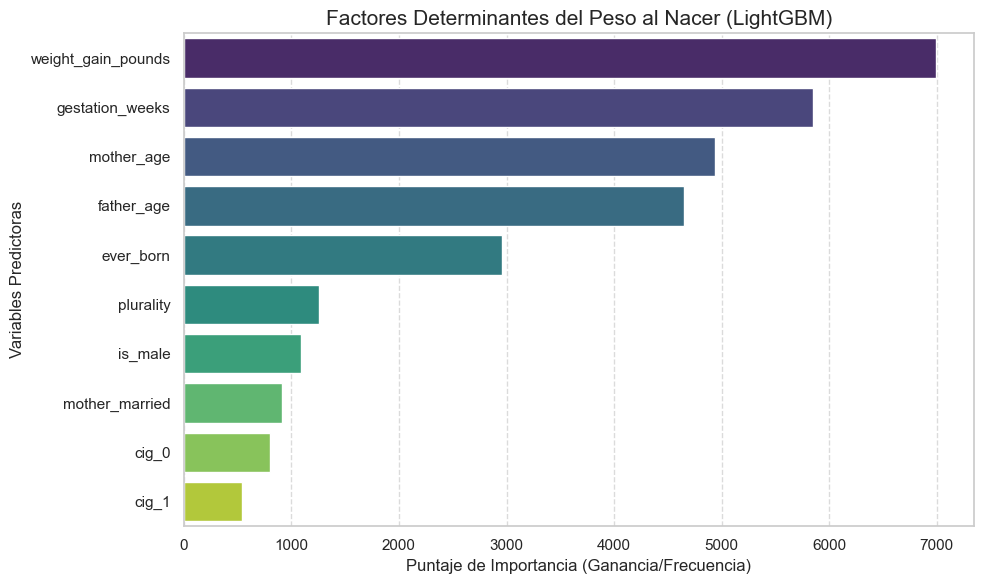

In [45]:
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': lgb_final.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# 2. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')
plt.title('Factores Determinantes del Peso al Nacer (LightGBM)', fontsize=15)
plt.xlabel('Puntaje de Importancia (Ganancia/Frecuencia)')
plt.ylabel('Variables Predictoras')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


X_train_rf = X_train.sample(n=100000, random_state=42)
y_train_rf = y_train.loc[X_train_rf.index]


rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

print("Iniciando búsqueda del mejor Random Forest...")
grid_rf.fit(X_train_rf, y_train_rf)

mejor_rf = grid_rf.best_estimator_
print("\n" + "="*45)
print("🏆 MEJOR RANDOM FOREST ENCONTRADO")
print("="*45)
print(f"Mejores Parámetros: {grid_rf.best_params_}")
print(f"Mejor MAE en validación: {-grid_svm.best_score_:.4f}")

Iniciando búsqueda del mejor Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

🏆 MEJOR RANDOM FOREST ENCONTRADO
Mejores Parámetros: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Mejor MAE en validación: 0.7909


In [ ]:
evaluar_modelo('lightgbm', y_real, y_pred